In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = "D:\PomegranateGuard\dataset"
CATEGORIES = ["Healthy", "Bacterial_Blight", "Anthracnose", "Fruit_Rot"]

print("Setup complete")
print("Categories:", CATEGORIES)

Setup complete
Categories: ['Healthy', 'Bacterial_Blight', 'Anthracnose', 'Fruit_Rot']


In [2]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

print("Preprocess function ready")


Preprocess function ready


Starting preprocessing...
Checking: D:\PomegranateGuard\dataset\Healthy
Healthy: 1450 images


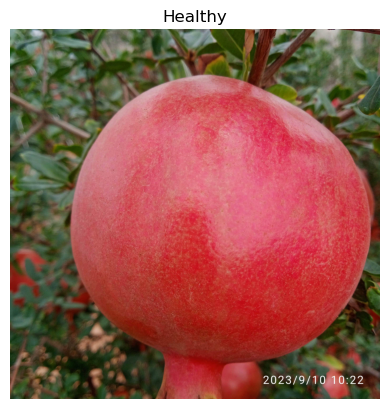

Checking: D:\PomegranateGuard\dataset\Bacterial_Blight
Bacterial_Blight: 1000 images


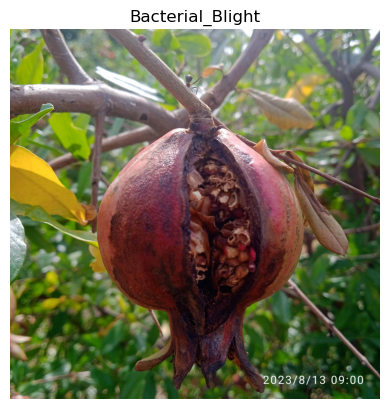

Checking: D:\PomegranateGuard\dataset\Anthracnose
Anthracnose: 1166 images


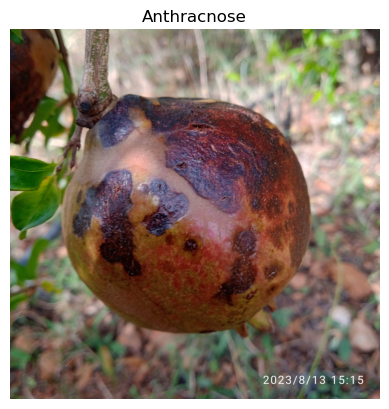

Checking: D:\PomegranateGuard\dataset\Fruit_Rot
Fruit_Rot: 2010 images


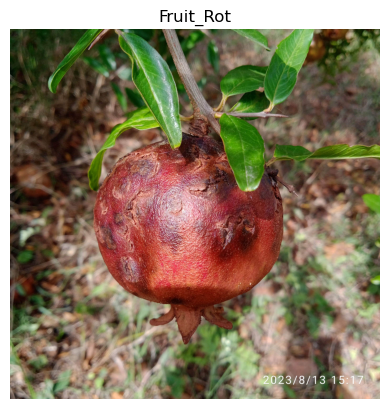

Total images loaded: 5626
X shape: (5626, 224, 224, 3)
y shape: (5626,)


In [3]:
print("Starting preprocessing...")

X = []
y = []

for category in CATEGORIES:
    path = os.path.join(DATASET_PATH, category)
    print("Checking:", path)

    images = os.listdir(path)
    print(f"{category}: {len(images)} images")

    sample_img_path = os.path.join(path, images[0])
    sample_img = cv2.imread(sample_img_path)
    sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

    plt.imshow(sample_img)
    plt.title(category)
    plt.axis("off")
    plt.show()
 
    for img_name in images:
        img_path = os.path.join(path, img_name)
        try:
            img = preprocess_image(img_path)
            X.append(img)
            y.append(CATEGORIES.index(category))
        except Exception as e:
            print("❌ Error with:", img_path)
            print(e)

X = np.array(X)
y = np.array(y)

print("Total images loaded:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)


In [4]:
np.save("D:\PomegranateGuard\dataset\X.npy", X)
np.save("D:\PomegranateGuard\dataset\y.npy", y)
print("Saved successfully")

Saved successfully
